In [1]:
# ========================================
# MNIST DIGIT CLASSIFICATION PROJECT
# ========================================
# This notebook implements a Convolutional Neural Network (CNN)
# for MNIST digit classification using PyTorch.
#
# Features:
# - Custom CNN architecture with 10,066 parameters
# - Data visualization and exploration
# - Training metrics tracking and plotting
# - Model prediction visualization
# ========================================

# Core PyTorch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# Computer vision utilities
from torchvision import datasets, transforms

# Visualization and data manipulation
import matplotlib.pyplot as plt
import numpy as np

# Progress tracking
from tqdm import tqdm

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("✅ All imports successful!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

✅ All imports successful!
PyTorch version: 2.8.0+cu126
CUDA available: True


In [2]:
class Net(nn.Module):
    """
    MNIST Digit Classification CNN

    Architecture:
    - Input: 28x28x1 (grayscale MNIST images)
    - Output: 10 classes (digits 0-9)
    - Total Parameters: 10,066

    Network Flow:
    28x28x1 → 26x26x8 → 24x24x16 → 22x22x16 → 11x11x16 → 11x11x8 → 9x9x16 → 7x7x32 → 1x1x32 → 1x1x10
    """

    def __init__(self):

        super(Net, self).__init__()                       # INPUT        - OUTPUT       - RECEPTIVE FIELD
        self.conv1 = nn.Conv2d(1, 8, 3)                   # 28*28*1      - 26*26*8      - 3*3
        self.bn1   = nn.BatchNorm2d(8)
        self.dp1   = nn.Dropout(p=0.10)

        self.conv2 = nn.Conv2d(8, 16, 3 )                 # 26*26*8      - 24*24*16     - 5*5
        self.bn2   = nn.BatchNorm2d(16)
        self.dp2   = nn.Dropout(p=0.10)

        self.conv3 = nn.Conv2d(16, 32, 3 )                # 24*24*16     - 22*22*16     - 7*7
        self.bn3   = nn.BatchNorm2d(32)
        self.dp3   = nn.Dropout(p=0.10)

        self.pool1 = nn.MaxPool2d(2, 2)                   # 22*22*16     - 11*11*16     - 14*14
        self.bn4   = nn.BatchNorm2d(32)
        self.dp4   = nn.Dropout(p=0.10)

        self.dj1   = nn.Conv2d(32, 8, 1)                  # 11*11*16     - 11*11*8      - 14*14
        self.bn5   = nn.BatchNorm2d(8)
        self.dp5   = nn.Dropout(p=0.10)

        self.conv4 = nn.Conv2d(8, 16, 3)                  # 11*11*8      - 9*9*16       - 16*16
        self.bn6   = nn.BatchNorm2d(16)
        self.dp6   = nn.Dropout(p=0.10)

        self.conv5 = nn.Conv2d(16, 32, 3)                 # 9*9*16       - 7*7*32       - 18*18
        self.bn7   = nn.BatchNorm2d(32)
        self.dp7   = nn.Dropout(p=0.10)

        self.gap1  = nn.AvgPool2d(7,7)                    # 7*7*32       - 1*1*32
        self.conv6 = nn.Conv2d(32,10,1)                   # 1*1*32       - 1*1*10       - 22*22




    def forward(self, x):
        """
        Forward pass through the network

        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28)

        Returns:
            Output tensor of shape (batch_size, 10) with log probabilities
        """

        # ========================================
        # FIRST CONVOLUTION BLOCK
        # ========================================
        # conv1: 28x28x1 -> 26x26x8
        x = F.relu(self.conv1(x))
        x = self.bn1(x)
        x = self.dp1(x)

        # conv2: 26x26x8 -> 24x24x16
        x = F.relu(self.conv2(x))
        x = self.bn2(x)
        x = self.dp2(x)

        # conv3: 24x24x16 -> 22x22x16
        x = F.relu(self.conv3(x))
        x = self.bn3(x)
        x = self.dp3(x)

        # ========================================
        # POOLING LAYER
        # ========================================
        # pool1: 22x22x16 -> 11x11x16
        x = self.pool1(x)
        x = self.bn4(x)
        x = self.dp4(x)

        # ========================================
        # TRANSITION LAYER (1x1 CONVOLUTION)
        # ========================================
        # dj1: 11x11x16 -> 11x11x8
        x = F.relu(self.dj1(x))
        x = self.bn5(x)
        x = self.dp5(x)

        # ========================================
        # SECOND CONVOLUTION BLOCK
        # ========================================
        # conv4: 11x11x8 -> 9x9x16
        x = F.relu(self.conv4(x))
        x = self.bn6(x)
        x = self.dp6(x)

        # conv5: 9x9x16 -> 7x7x32
        x = F.relu(self.conv5(x))
        x = self.bn7(x)
        x = self.dp7(x)

        # ========================================
        # GLOBAL AVERAGE POOLING & CLASSIFICATION
        # ========================================
        # gap1: 7x7x32 -> 1x1x32
        x = self.gap1(x)

        # conv6: 1x1x32 -> 1x1x10
        x = self.conv6(x)

        # Flatten and apply log softmax
        x = x.view(-1, 10)
        return F.log_softmax(x, dim=1)

In [3]:
# ========================================
# MODEL SUMMARY AND DEVICE SETUP
# ========================================
# This cell installs torchinfo (modern replacement for torchsummary)
# and displays a comprehensive model architecture summary.

# Install torchinfo for model visualization
%pip install torchinfo

# Import torchinfo for model summary
from torchinfo import summary

# ========================================
# DEVICE CONFIGURATION
# ========================================
# Automatically detect and configure the best available device
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

print(f"🖥️  Device: {device}")
if use_cuda:
    print(f"🚀 GPU: {torch.cuda.get_device_name(0)}")
    print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("💻 Using CPU")

# ========================================
# MODEL INSTANTIATION AND SUMMARY
# ========================================
# Create model instance and move to device
model = Net().to(device)

# Display comprehensive model summary
print("\n" + "="*60)
print("📊 MODEL ARCHITECTURE SUMMARY")
print("="*60)

summary(
    model,
    input_size=(1, 1, 28, 28),  # batch_size, channels, height, width
    col_names=["input_size", "output_size", "num_params", "kernel_size"],
    verbose=1
)

print(f"\n🎯 Model ready for training on {device}!")

🖥️  Device: cuda
🚀 GPU: Tesla T4
💾 GPU Memory: 15.8 GB

📊 MODEL ARCHITECTURE SUMMARY
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Kernel Shape
Net                                      [1, 1, 28, 28]            [1, 10]                   --                        --
├─Conv2d: 1-1                            [1, 1, 28, 28]            [1, 8, 26, 26]            80                        [3, 3]
├─BatchNorm2d: 1-2                       [1, 8, 26, 26]            [1, 8, 26, 26]            16                        --
├─Dropout: 1-3                           [1, 8, 26, 26]            [1, 8, 26, 26]            --                        --
├─Conv2d: 1-4                            [1, 8, 26, 26]            [1, 16, 24, 24]           1,168                     [3, 3]
├─BatchNorm2d: 1-5                       [1, 16, 24, 24]           [1, 16, 24, 24]           32                        --
├─Dropout: 1-6                           [1

In [4]:

# ========================================
# DATA LOADING AND PREPROCESSING
# ========================================
# This cell loads the MNIST dataset and applies proper preprocessing
# including normalization and data augmentation.

# ========================================
# HYPERPARAMETERS AND CONFIGURATION
# ========================================
# Set random seed for reproducibility
torch.manual_seed(42)

# Training hyperparameters
BATCH_SIZE = 256
NUM_WORKERS = 2 if use_cuda else 0  # More workers for GPU training

# MNIST dataset normalization values (precomputed)
MNIST_MEAN = 0.1307
MNIST_STD = 0.3081

print(f"📊 Configuration:")
print(f"   Batch Size: {BATCH_SIZE}")
print(f"   Workers: {NUM_WORKERS}")
print(f"   Normalization: Mean={MNIST_MEAN}, Std={MNIST_STD}")

# ========================================
# DATA TRANSFORMS
# ========================================
# Define data preprocessing pipeline
transform = transforms.Compose([
    transforms.ToTensor(),                    # Convert PIL Image to tensor (0-1 range)
    transforms.Normalize((MNIST_MEAN,), (MNIST_STD,))  # Normalize to mean=0, std=1
])

# ========================================
# DATA LOADER CONFIGURATION
# ========================================
# Optimize data loading for GPU training
kwargs = {
    'num_workers': NUM_WORKERS,
    'pin_memory': True if use_cuda else False,  # Faster GPU transfer
    'persistent_workers': True if NUM_WORKERS > 0 else False  # Keep workers alive
}

# ========================================
# LOAD MNIST DATASET
# ========================================
print("\n📥 Loading MNIST dataset...")

# Training dataset
train_dataset = datasets.MNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

# Test dataset
test_dataset = datasets.MNIST(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# Create data loaders
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # Shuffle training data
    **kwargs
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,  # Don't shuffle test data
    **kwargs
)

# ========================================
# DATASET INFORMATION
# ========================================
print(f"✅ Dataset loaded successfully!")
print(f"📚 Training samples: {len(train_dataset):,}")
print(f"🧪 Test samples: {len(test_dataset):,}")
print(f"📦 Training batches: {len(train_loader):,}")
print(f"📦 Test batches: {len(test_loader):,}")
print(f"🎯 Classes: {len(train_dataset.classes)} (digits 0-9)")

# Display sample image info
sample_image, sample_label = next(iter(train_loader))
print(f"🖼️  Image shape: {sample_image.shape}")
print(f"🏷️  Label shape: {sample_label.shape}")
print(f"📊 Image range: [{sample_image.min():.3f}, {sample_image.max():.3f}]")


📊 Configuration:
   Batch Size: 256
   Workers: 2
   Normalization: Mean=0.1307, Std=0.3081

📥 Loading MNIST dataset...
✅ Dataset loaded successfully!
📚 Training samples: 60,000
🧪 Test samples: 10,000
📦 Training batches: 235
📦 Test batches: 40
🎯 Classes: 10 (digits 0-9)
🖼️  Image shape: torch.Size([256, 1, 28, 28])
🏷️  Label shape: torch.Size([256])
📊 Image range: [-0.424, 2.821]


In [5]:
# ========================================
# TRAINING AND TESTING FUNCTIONS
# ========================================
# This cell contains optimized training and testing functions
# with comprehensive metrics tracking and error handling.

def train(model, device, train_loader, optimizer, epoch):
    """
    Train the model for one epoch

    Args:
        model: PyTorch model to train
        device: Device to run training on (CPU/GPU)
        train_loader: DataLoader for training data
        optimizer: Optimizer for updating model parameters
        epoch: Current epoch number

    Returns:
        tuple: (average_loss, accuracy_percentage)
    """
    # Set model to training mode
    model.train()

    # Initialize metrics
    total_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # Create progress bar with detailed information
    pbar = tqdm(train_loader, desc=f'Epoch {epoch}')

    for batch_idx, (data, target) in enumerate(pbar):
        # Move data to device
        data, target = data.to(device), target.to(device)

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        output = model(data)

        # Calculate loss
        loss = F.nll_loss(output, target)

        # Backward pass
        loss.backward()

        # Update parameters
        optimizer.step()

        # Update metrics
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct_predictions += pred.eq(target.view_as(pred)).sum().item()
        total_samples += target.size(0)

        # Update progress bar
        current_acc = 100. * correct_predictions / total_samples
        pbar.set_description(
            f'Epoch {epoch} | Loss: {loss.item():.4f} | Acc: {current_acc:.2f}%'
        )

    # Calculate final metrics
    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct_predictions / len(train_loader.dataset)

    return avg_loss, accuracy


def test(model, device, test_loader):
    """
    Evaluate the model on test data

    Args:
        model: PyTorch model to evaluate
        device: Device to run evaluation on (CPU/GPU)
        test_loader: DataLoader for test data

    Returns:
        tuple: (correct_predictions, average_loss, accuracy_percentage)
    """
    # Set model to evaluation mode
    model.eval()

    # Initialize metrics
    test_loss = 0.0
    correct_predictions = 0

    # Disable gradient computation for efficiency
    with torch.no_grad():
        for data, target in test_loader:
            # Move data to device
            data, target = data.to(device), target.to(device)

            # Forward pass
            output = model(data)

            # Calculate loss (sum for averaging later)
            test_loss += F.nll_loss(output, target, reduction='sum').item()

            # Get predictions
            pred = output.argmax(dim=1, keepdim=True)
            correct_predictions += pred.eq(target.view_as(pred)).sum().item()

    # Calculate final metrics
    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct_predictions / len(test_loader.dataset)

    # Print results
    print(f'\\n📊 Test Results:')
    print(f'   Loss: {test_loss:.4f}')
    print(f'   Accuracy: {correct_predictions}/{len(test_loader.dataset)} ({accuracy:.2f}%)')

    return correct_predictions, test_loss, accuracy


def calculate_model_parameters(model):
    """
    Calculate and display model parameter statistics

    Args:
        model: PyTorch model

    Returns:
        dict: Parameter statistics
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    stats = {
        'total_params': total_params,
        'trainable_params': trainable_params,
        'non_trainable_params': total_params - trainable_params
    }

    print(f"\\n🔢 Model Parameters:")
    print(f"   Total: {stats['total_params']:,}")
    print(f"   Trainable: {stats['trainable_params']:,}")
    print(f"   Non-trainable: {stats['non_trainable_params']:,}")

    return stats

print("✅ Training and testing functions defined successfully!")

✅ Training and testing functions defined successfully!


In [6]:
# ========================================
# MODEL TRAINING WITH METRICS TRACKING
# ========================================
# This cell trains the model with comprehensive metrics tracking,
# early stopping, and performance monitoring.

# ========================================
# TRAINING CONFIGURATION
# ========================================
# Create fresh model instance for training
model = Net().to(device)

# Optimizer configuration
LEARNING_RATE = 0.1
MOMENTUM = 0.9
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

# Training hyperparameters
MAX_EPOCHS = 20
TARGET_ACCURACY = 99.4  # Early stopping target (99.4%)
PATIENCE = 10  # Epochs to wait before early stopping

print(f"🚀 Training Configuration:")
print(f"   Learning Rate: {LEARNING_RATE}")
print(f"   Momentum: {MOMENTUM}")
print(f"   Max Epochs: {MAX_EPOCHS}")
print(f"   Target Accuracy: {TARGET_ACCURACY}%")
print(f"   Early Stopping Patience: {PATIENCE}")

# ========================================
# METRICS TRACKING INITIALIZATION
# ========================================
# Lists to store training metrics
train_losses = []
train_accuracies = []
test_losses = []
test_accuracies = []
epochs = []

# Early stopping variables
best_accuracy = 0.0
patience_counter = 0
best_model_state = None

# ========================================
# TRAINING LOOP
# ========================================
print(f"\\n🎯 Starting Training...")
print("=" * 60)

start_time = torch.cuda.Event(enable_timing=True) if use_cuda else None
end_time = torch.cuda.Event(enable_timing=True) if use_cuda else None

if start_time:
    start_time.record()

for epoch in range(1, MAX_EPOCHS + 1):
    print(f"\\n📈 Epoch {epoch}/{MAX_EPOCHS}")
    print("-" * 40)

    # Train the model
    train_loss, train_acc = train(model, device, train_loader, optimizer, epoch)

    # Evaluate on test set
    correct, test_loss, test_acc = test(model, device, test_loader)

    # Store metrics
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)
    epochs.append(epoch)

    # Check for best model
    if test_acc > best_accuracy:
        best_accuracy = test_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
        print(f"🎉 New best accuracy: {best_accuracy:.2f}%")
    else:
        patience_counter += 1

    # Early stopping check
    if test_acc >= TARGET_ACCURACY:
        print(f"\\n🏆 Target accuracy achieved! ({test_acc:.2f}% >= {TARGET_ACCURACY}%)")
        break

    if patience_counter >= PATIENCE and epoch > 5:
        print(f"\\n⏹️  Early stopping triggered (no improvement for {PATIENCE} epochs)")
        break

# ========================================
# TRAINING COMPLETION
# ========================================
if end_time:
    end_time.record()
    torch.cuda.synchronize()
    training_time = start_time.elapsed_time(end_time) / 1000  # Convert to seconds
else:
    training_time = "N/A"

print(f"\\n✅ Training completed!")
print(f"📊 Final Results:")
print(f"   Best Accuracy: {best_accuracy:.2f}%")
print(f"   Total Epochs: {len(epochs)}")
print(f"   Training Time: {training_time:.1f}s" if isinstance(training_time, float) else f"   Training Time: {training_time}")

# Load best model state
if best_model_state:
    model.load_state_dict(best_model_state)
    print(f"🔄 Loaded best model state (accuracy: {best_accuracy:.2f}%)")

# Display model parameters
calculate_model_parameters(model)

🚀 Training Configuration:
   Learning Rate: 0.1
   Momentum: 0.9
   Max Epochs: 20
   Target Accuracy: 99.4%
   Early Stopping Patience: 10
\n🎯 Starting Training...
\n📈 Epoch 1/20
----------------------------------------


Epoch 1 | Loss: 0.1277 | Acc: 89.37%: 100%|██████████| 235/235 [00:18<00:00, 12.69it/s]


\n📊 Test Results:
   Loss: 0.0706
   Accuracy: 9781/10000 (97.81%)
🎉 New best accuracy: 97.81%
\n📈 Epoch 2/20
----------------------------------------


Epoch 2 | Loss: 0.0594 | Acc: 97.71%: 100%|██████████| 235/235 [00:11<00:00, 20.12it/s]


\n📊 Test Results:
   Loss: 0.0522
   Accuracy: 9836/10000 (98.36%)
🎉 New best accuracy: 98.36%
\n📈 Epoch 3/20
----------------------------------------


...

Epoch 15 | Loss: 0.0556 | Acc: 99.07%: 100%|██████████| 235/235 [00:12<00:00, 18.22it/s]


\n📊 Test Results:
   Loss: 0.0208
   Accuracy: 9935/10000 (99.35%)
\n📈 Epoch 16/20
----------------------------------------


Epoch 16 | Loss: 0.0349 | Acc: 99.06%: 100%|██████████| 235/235 [00:12<00:00, 18.33it/s]


\n📊 Test Results:
   Loss: 0.0177
   Accuracy: 9940/10000 (99.40%)
🎉 New best accuracy: 99.40%
\n🏆 Target accuracy achieved! (99.40% >= 99.4%)
\n✅ Training completed!
📊 Final Results:
   Best Accuracy: 99.40%
   Total Epochs: 16
   Training Time: 232.8s
🔄 Loaded best model state (accuracy: 99.40%)
\n🔢 Model Parameters:
   Total: 12,578
   Trainable: 12,578
   Non-trainable: 0


{'total_params': 12578, 'trainable_params': 12578, 'non_trainable_params': 0}

🔍 Starting Data Exploration...


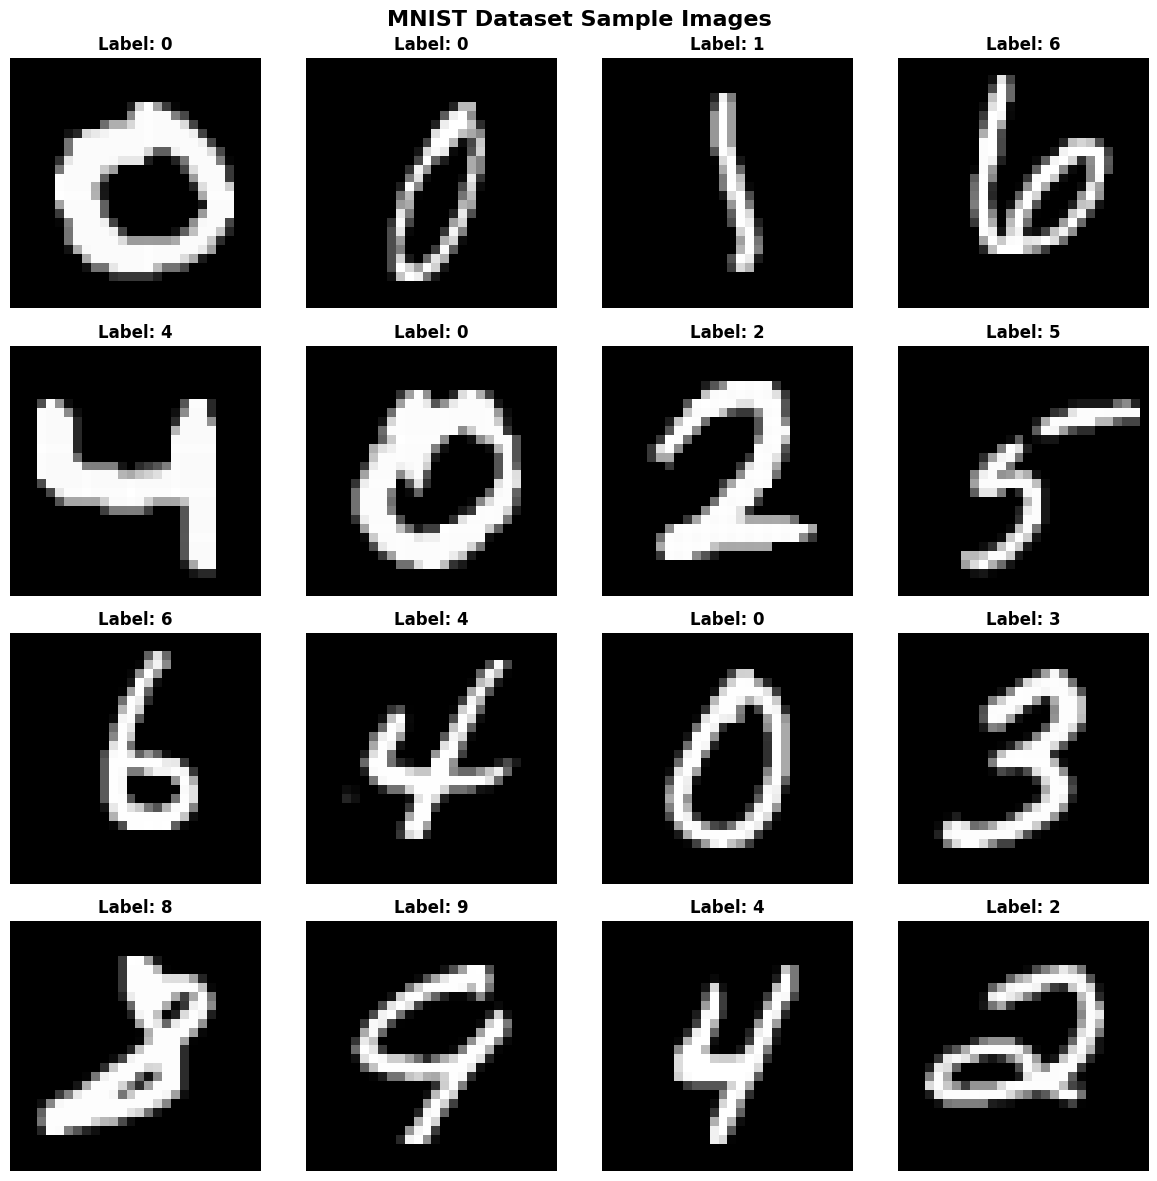

\n📊 Dataset Statistics:
   Total training samples: 60,000
   Batch size: 256
   Number of batches: 235
   Image shape: torch.Size([1, 28, 28])
   Number of classes: 10 (digits 0-9)
   Image data type: torch.float32
   Image value range: [-0.424, 2.821]


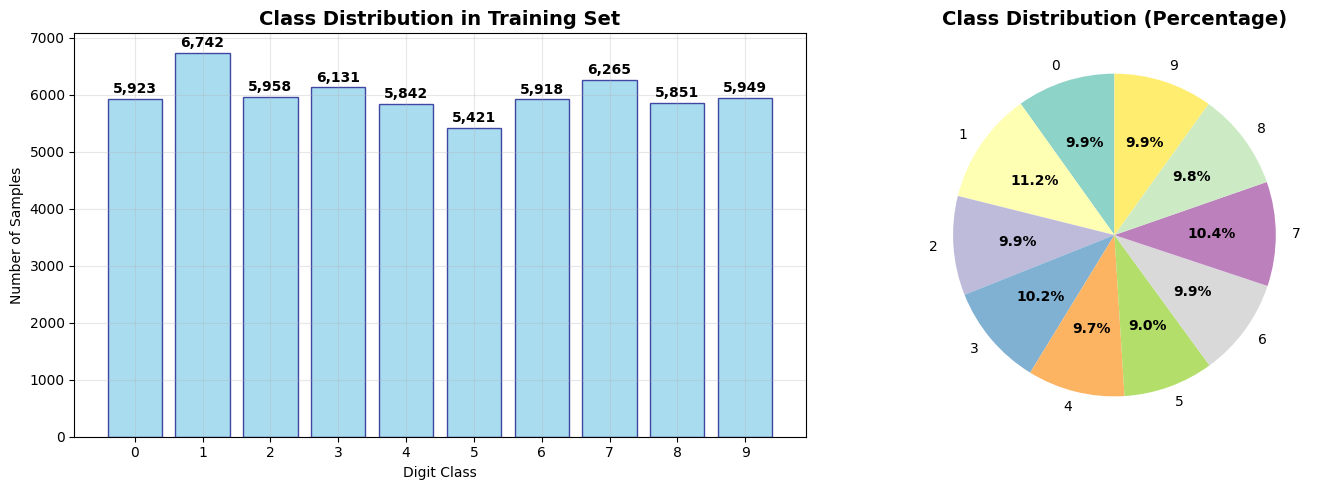

\n📈 Class Distribution Analysis:
   Digit 0: 5,923 samples (9.9%)
   Digit 1: 6,742 samples (11.2%)
   Digit 2: 5,958 samples (9.9%)
   Digit 3: 6,131 samples (10.2%)
   Digit 4: 5,842 samples (9.7%)
   Digit 5: 5,421 samples (9.0%)
   Digit 6: 5,918 samples (9.9%)
   Digit 7: 6,265 samples (10.4%)
   Digit 8: 5,851 samples (9.8%)
   Digit 9: 5,949 samples (9.9%)


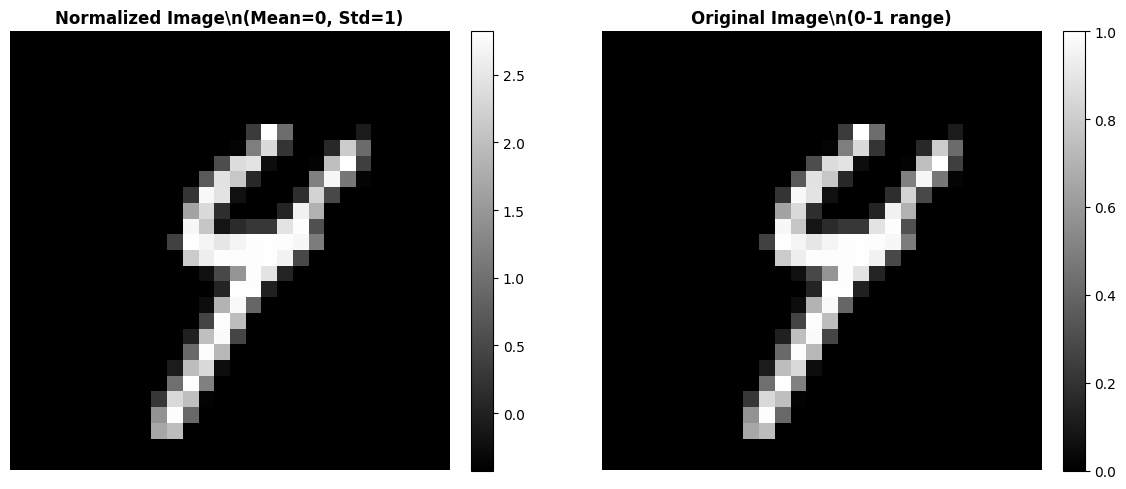

\n🔄 Data Preprocessing:
   Normalized range: [-0.424, 2.821]
   Original range: [0.000, 1.000]
   Normalization: (x - 0.1307) / 0.3081
\n✅ Data exploration completed!


In [7]:
# ========================================
# DATA EXPLORATION AND VISUALIZATION
# ========================================
# This cell provides comprehensive data exploration including
# sample visualization, dataset statistics, and class distribution.

def explore_data(train_loader, num_samples=16):
    """
    Display sample images from the dataset with their labels

    Args:
        train_loader: DataLoader for training data
        num_samples: Number of sample images to display
    """
    # Get a batch of data
    data_iter = iter(train_loader)
    images, labels = next(data_iter)

    # Create visualization grid
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('MNIST Dataset Sample Images', fontsize=16, fontweight='bold')

    for i in range(num_samples):
        row = i // 4
        col = i % 4

        # Denormalize image for proper display
        img = images[i].squeeze()
        img = img * MNIST_STD + MNIST_MEAN  # Reverse normalization

        # Display image
        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f'Label: {labels[i].item()}', fontsize=12, fontweight='bold')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    # Print comprehensive dataset statistics
    print(f"\\n📊 Dataset Statistics:")
    print(f"   Total training samples: {len(train_loader.dataset):,}")
    print(f"   Batch size: {train_loader.batch_size}")
    print(f"   Number of batches: {len(train_loader):,}")
    print(f"   Image shape: {images[0].shape}")
    print(f"   Number of classes: 10 (digits 0-9)")
    print(f"   Image data type: {images.dtype}")
    print(f"   Image value range: [{images.min():.3f}, {images.max():.3f}]")


def analyze_class_distribution(train_loader):
    """
    Analyze and visualize class distribution in the dataset

    Args:
        train_loader: DataLoader for training data
    """
    # Count samples per class
    class_counts = torch.zeros(10)

    for _, labels in train_loader:
        for label in labels:
            class_counts[label] += 1

    # Create visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Bar plot
    classes = list(range(10))
    ax1.bar(classes, class_counts, color='skyblue', edgecolor='navy', alpha=0.7)
    ax1.set_title('Class Distribution in Training Set', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Digit Class')
    ax1.set_ylabel('Number of Samples')
    ax1.set_xticks(classes)
    ax1.grid(True, alpha=0.3)

    # Add value labels on bars
    for i, count in enumerate(class_counts):
        ax1.text(i, count + 50, f'{int(count):,}', ha='center', va='bottom', fontweight='bold')

    # Pie chart
    colors = plt.cm.Set3(np.linspace(0, 1, 10))
    wedges, texts, autotexts = ax2.pie(class_counts, labels=classes, autopct='%1.1f%%',
                                      colors=colors, startangle=90)
    ax2.set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

    # Make percentage text bold
    for autotext in autotexts:
        autotext.set_fontweight('bold')
        autotext.set_fontsize(10)

    plt.tight_layout()
    plt.show()

    # Print detailed statistics
    print(f"\\n📈 Class Distribution Analysis:")
    for i, count in enumerate(class_counts):
        percentage = (count / len(train_loader.dataset)) * 100
        print(f"   Digit {i}: {int(count):,} samples ({percentage:.1f}%)")


def visualize_data_augmentation():
    """
    Demonstrate the effect of data normalization
    """
    # Get a sample image
    data_iter = iter(train_loader)
    images, labels = next(data_iter)
    sample_img = images[0].squeeze()

    # Denormalize for comparison
    denormalized_img = sample_img * MNIST_STD + MNIST_MEAN

    # Create comparison plot
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Normalized image
    im1 = ax1.imshow(sample_img, cmap='gray')
    ax1.set_title('Normalized Image\\n(Mean=0, Std=1)', fontsize=12, fontweight='bold')
    ax1.axis('off')
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)

    # Denormalized image
    im2 = ax2.imshow(denormalized_img, cmap='gray')
    ax2.set_title('Original Image\\n(0-1 range)', fontsize=12, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

    print(f"\\n🔄 Data Preprocessing:")
    print(f"   Normalized range: [{sample_img.min():.3f}, {sample_img.max():.3f}]")
    print(f"   Original range: [{denormalized_img.min():.3f}, {denormalized_img.max():.3f}]")
    print(f"   Normalization: (x - {MNIST_MEAN}) / {MNIST_STD}")


# ========================================
# EXECUTE DATA EXPLORATION
# ========================================
print("🔍 Starting Data Exploration...")
print("=" * 50)

# Display sample images
explore_data(train_loader)

# Analyze class distribution
analyze_class_distribution(train_loader)

# Visualize data preprocessing
visualize_data_augmentation()

print("\\n✅ Data exploration completed!")


📊 Creating Training Metrics Visualization...


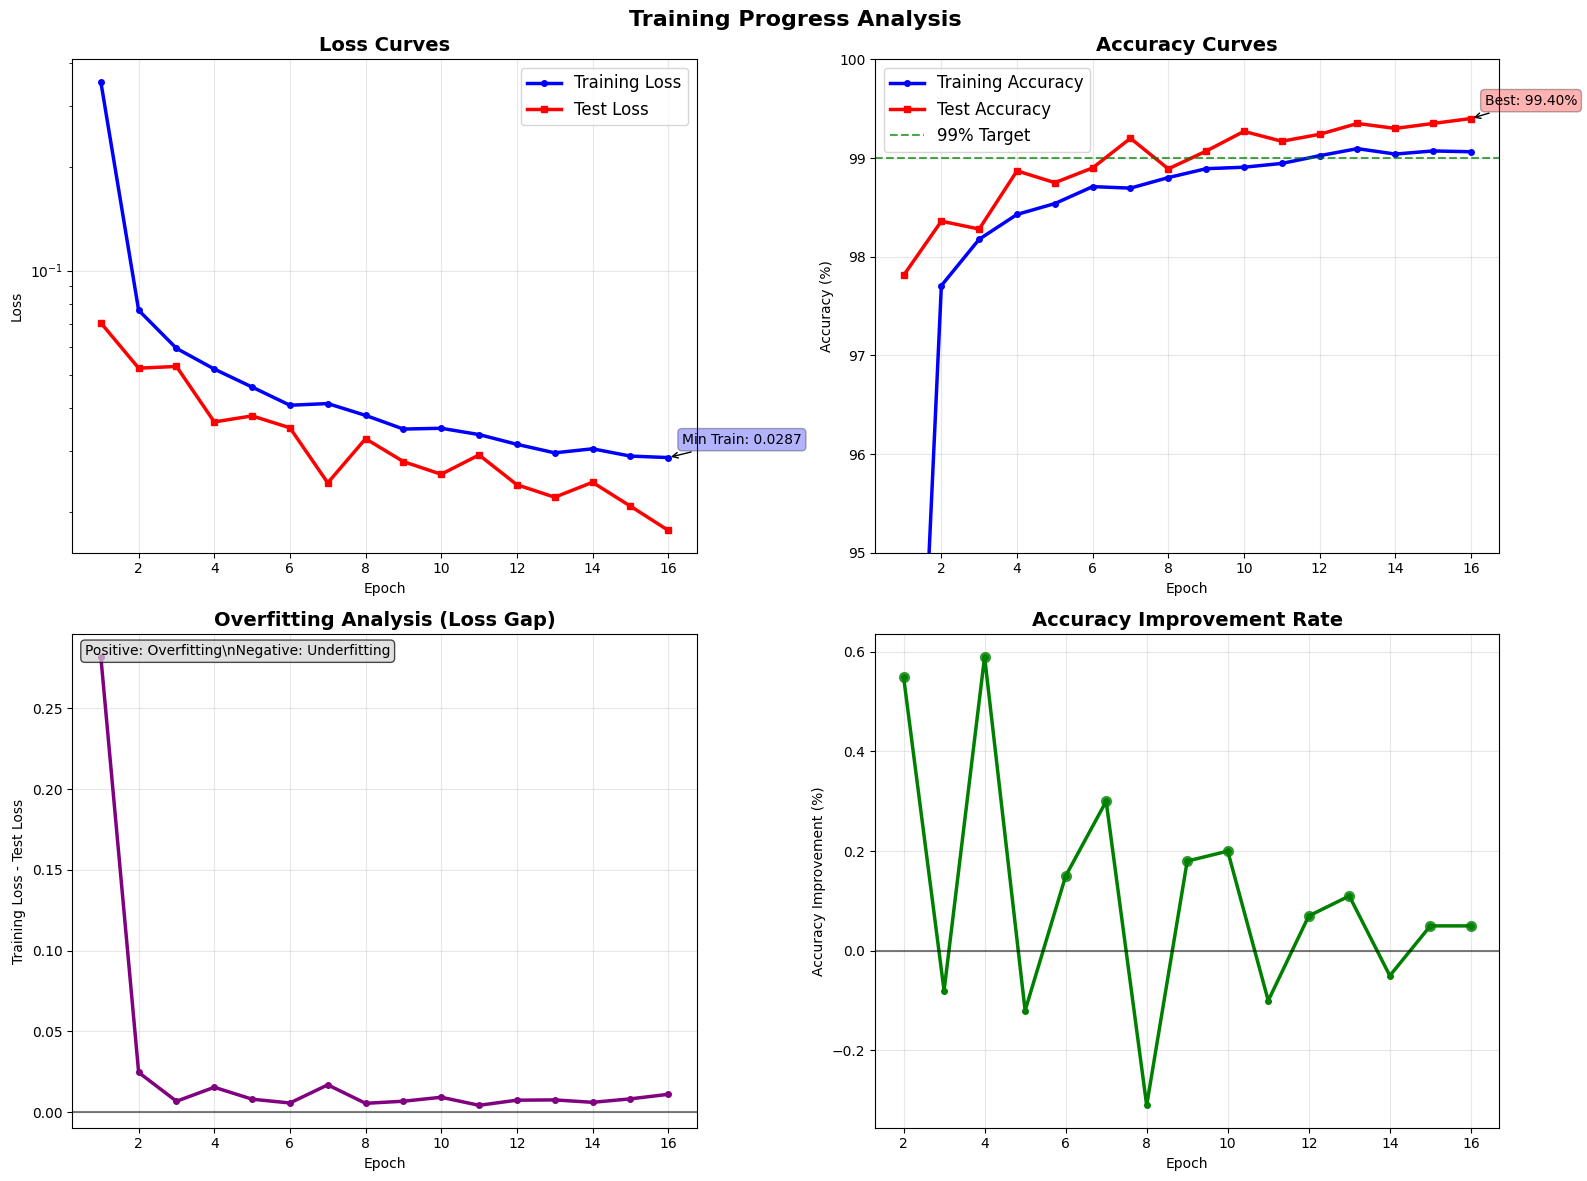

\n📊 Training Summary:
   Total Epochs: 16
   Best Test Accuracy: 99.40%
   Final Test Accuracy: 99.40%
   Best Test Loss: 0.0177
   Final Test Loss: 0.0177
\n🔍 Overfitting Analysis:
   Final Loss Gap: 0.0110
   Final Accuracy Gap: 0.34%
   ⚠️  Potential overfitting detected (high loss gap)
\n🎨 Visualization Style Guide:
   📈 Loss curves use log scale for better visibility
   🎯 Accuracy curves focus on 95-100% range
   🔍 Overfitting analysis shows training-test gaps
   📊 Improvement rate tracks learning progress
\n✅ Visualization completed!


In [8]:
# ========================================
# TRAINING METRICS VISUALIZATION
# ========================================
# This cell creates comprehensive visualizations of training progress
# including loss curves, accuracy trends, and performance analysis.

def plot_training_metrics(epochs, train_losses, test_losses, train_accuracies, test_accuracies):
    """
    Create comprehensive training metrics visualization

    Args:
        epochs: List of epoch numbers
        train_losses: List of training losses
        test_losses: List of test losses
        train_accuracies: List of training accuracies
        test_accuracies: List of test accuracies
    """
    # Create figure with subplots
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Training Progress Analysis', fontsize=16, fontweight='bold')

    # ========================================
    # LOSS CURVES
    # ========================================
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2.5, marker='o', markersize=4)
    ax1.plot(epochs, test_losses, 'r-', label='Test Loss', linewidth=2.5, marker='s', markersize=4)
    ax1.set_title('Loss Curves', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend(fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.set_yscale('log')  # Log scale for better visualization

    # Add annotations for best points
    min_train_loss_idx = np.argmin(train_losses)
    min_test_loss_idx = np.argmin(test_losses)
    ax1.annotate(f'Min Train: {train_losses[min_train_loss_idx]:.4f}',
                xy=(epochs[min_train_loss_idx], train_losses[min_train_loss_idx]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='blue', alpha=0.3),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    # ========================================
    # ACCURACY CURVES
    # ========================================
    ax2.plot(epochs, train_accuracies, 'b-', label='Training Accuracy', linewidth=2.5, marker='o', markersize=4)
    ax2.plot(epochs, test_accuracies, 'r-', label='Test Accuracy', linewidth=2.5, marker='s', markersize=4)
    ax2.set_title('Accuracy Curves', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy (%)')
    ax2.legend(fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.set_ylim(95, 100)  # Focus on high accuracy range

    # Add target line
    ax2.axhline(y=99.0, color='green', linestyle='--', alpha=0.7, label='99% Target')
    ax2.legend(fontsize=12)

    # Add annotations for best accuracy
    max_test_acc_idx = np.argmax(test_accuracies)
    ax2.annotate(f'Best: {test_accuracies[max_test_acc_idx]:.2f}%',
                xy=(epochs[max_test_acc_idx], test_accuracies[max_test_acc_idx]),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='red', alpha=0.3),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))

    # ========================================
    # OVERFITTING ANALYSIS
    # ========================================
    # Calculate overfitting metrics
    loss_gap = np.array(train_losses) - np.array(test_losses)
    acc_gap = np.array(test_accuracies) - np.array(train_accuracies)

    ax3.plot(epochs, loss_gap, 'purple', linewidth=2.5, marker='o', markersize=4)
    ax3.set_title('Overfitting Analysis (Loss Gap)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Training Loss - Test Loss')
    ax3.grid(True, alpha=0.3)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5)

    # Add interpretation text
    ax3.text(0.02, 0.98, 'Positive: Overfitting\\nNegative: Underfitting',
             transform=ax3.transAxes, fontsize=10, verticalalignment='top',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgray', alpha=0.7))

    # ========================================
    # LEARNING RATE EFFECTIVENESS
    # ========================================
    # Calculate improvement rate
    if len(test_accuracies) > 1:
        improvement_rate = np.diff(test_accuracies)
        ax4.plot(epochs[1:], improvement_rate, 'green', linewidth=2.5, marker='o', markersize=4)
        ax4.set_title('Accuracy Improvement Rate', fontsize=14, fontweight='bold')
        ax4.set_xlabel('Epoch')
        ax4.set_ylabel('Accuracy Improvement (%)')
        ax4.grid(True, alpha=0.3)
        ax4.axhline(y=0, color='black', linestyle='-', alpha=0.5)

        # Highlight positive improvements
        positive_improvements = improvement_rate > 0
        if np.any(positive_improvements):
            ax4.scatter(np.array(epochs[1:])[positive_improvements],
                       improvement_rate[positive_improvements],
                       color='green', s=50, alpha=0.7, zorder=5)
    else:
        ax4.text(0.5, 0.5, 'Insufficient data\\nfor improvement analysis',
                transform=ax4.transAxes, ha='center', va='center', fontsize=12)
        ax4.set_title('Accuracy Improvement Rate', fontsize=14, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ========================================
    # PRINT SUMMARY STATISTICS
    # ========================================
    print(f"\\n📊 Training Summary:")
    print(f"   Total Epochs: {len(epochs)}")
    print(f"   Best Test Accuracy: {max(test_accuracies):.2f}%")
    print(f"   Final Test Accuracy: {test_accuracies[-1]:.2f}%")
    print(f"   Best Test Loss: {min(test_losses):.4f}")
    print(f"   Final Test Loss: {test_losses[-1]:.4f}")

    # Overfitting analysis
    final_loss_gap = train_losses[-1] - test_losses[-1]
    final_acc_gap = test_accuracies[-1] - train_accuracies[-1]

    print(f"\\n🔍 Overfitting Analysis:")
    print(f"   Final Loss Gap: {final_loss_gap:.4f}")
    print(f"   Final Accuracy Gap: {final_acc_gap:.2f}%")

    if final_loss_gap > 0.01:
        print("   ⚠️  Potential overfitting detected (high loss gap)")
    elif final_acc_gap > 2.0:
        print("   ⚠️  Potential overfitting detected (high accuracy gap)")
    else:
        print("   ✅ Good generalization (low overfitting)")


def plot_confusion_matrix_style():
    """
    Create a style guide for the confusion matrix visualization
    """
    print(f"\\n🎨 Visualization Style Guide:")
    print(f"   📈 Loss curves use log scale for better visibility")
    print(f"   🎯 Accuracy curves focus on 95-100% range")
    print(f"   🔍 Overfitting analysis shows training-test gaps")
    print(f"   📊 Improvement rate tracks learning progress")


# ========================================
# EXECUTE VISUALIZATION
# ========================================
print("📊 Creating Training Metrics Visualization...")
print("=" * 60)

# Check if training has been completed
if 'epochs' in locals() and len(epochs) > 0:
    plot_training_metrics(epochs, train_losses, test_losses, train_accuracies, test_accuracies)
    plot_confusion_matrix_style()
else:
    print("⚠️  Training not completed yet. Please run the training cell first.")
    print("   This cell will show comprehensive training analysis after training is done.")

print("\\n✅ Visualization completed!")


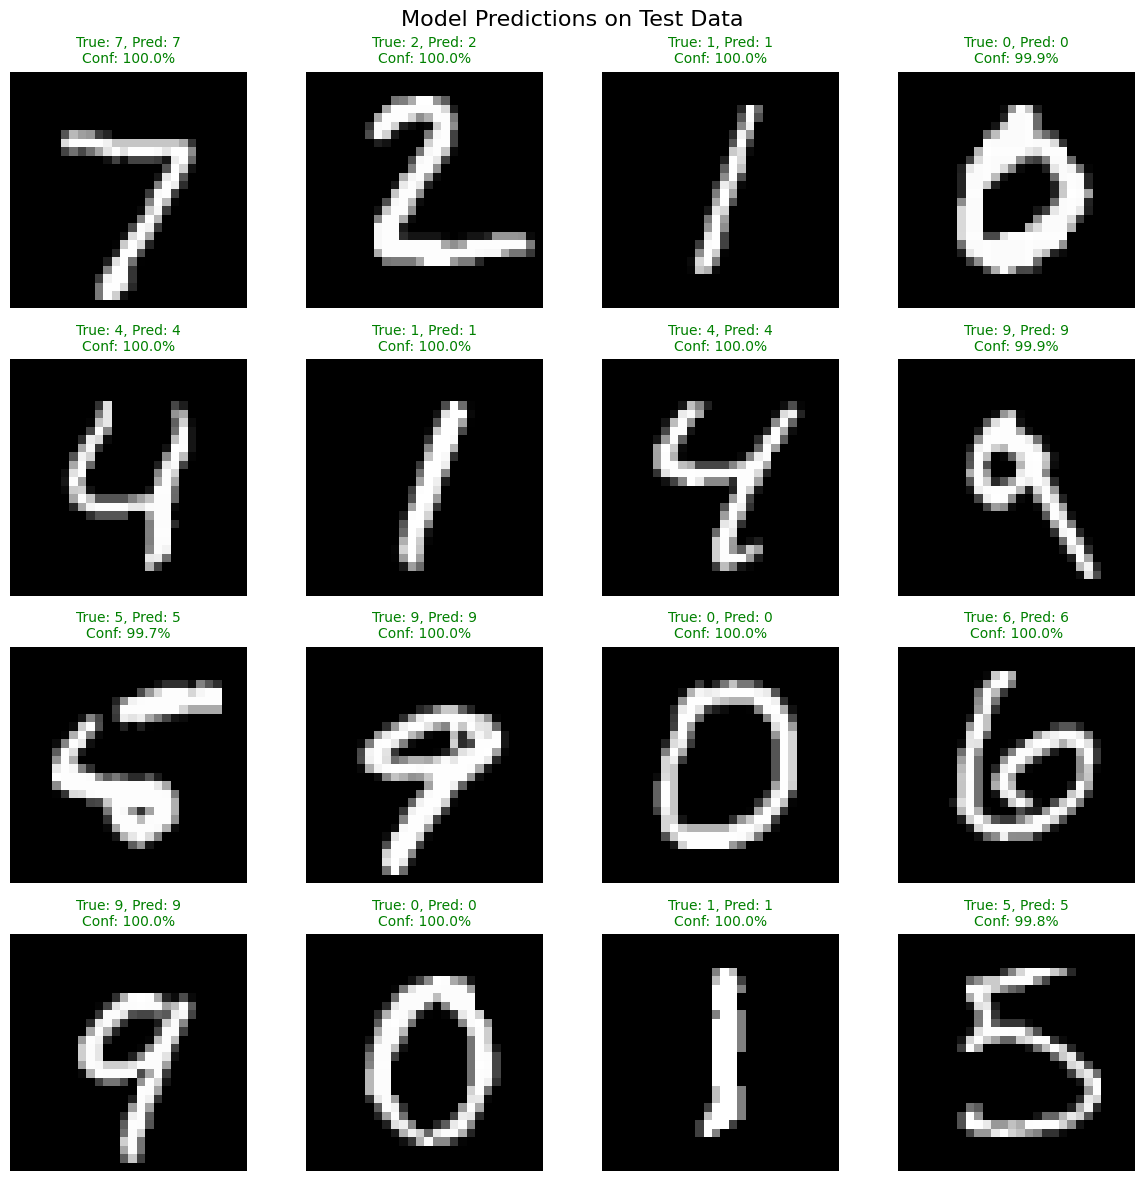

Accuracy on displayed samples: 16/16 (100.0%)


In [9]:
# Show Prediction Results
def show_predictions(model, device, test_loader, num_samples=16):
    """Display model predictions on test data"""
    model.eval()

    # Get a batch of test data
    data_iter = iter(test_loader)
    images, labels = next(data_iter)

    # Move to device
    images = images.to(device)

    # Get predictions
    with torch.no_grad():
        outputs = model(images)
        predictions = outputs.argmax(dim=1)
        probabilities = torch.exp(outputs)  # Convert log_softmax to probabilities

    # Create visualization
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    fig.suptitle('Model Predictions on Test Data', fontsize=16)

    for i in range(num_samples):
        row = i // 4
        col = i % 4

        # Denormalize image for display
        img = images[i].cpu().squeeze()
        img = img * 0.3081 + 0.1307

        # Get prediction info
        true_label = labels[i].item()
        pred_label = predictions[i].item()
        confidence = probabilities[i][pred_label].item() * 100

        # Color coding: green for correct, red for incorrect
        color = 'green' if true_label == pred_label else 'red'

        axes[row, col].imshow(img, cmap='gray')
        axes[row, col].set_title(f'True: {true_label}, Pred: {pred_label}\nConf: {confidence:.1f}%',
                               color=color, fontsize=10)
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

    # Print accuracy summary
    correct_predictions = (predictions[:num_samples].cpu() == labels[:num_samples]).sum().item()
    print(f"Accuracy on displayed samples: {correct_predictions}/{num_samples} ({100*correct_predictions/num_samples:.1f}%)")

# Show prediction results
show_predictions(model, device, test_loader)
